# 02 Bedrock Vadose-Zone Storage Capacity

Documents the neutron-probe storage workflow and generates the bedrock vadose-zone storage capacity figure and table. The processed storage time series used by the manuscript is included in `Data/storage_ts.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import TheilSenRegressor
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid
from scipy.optimize import curve_fit
import math
import os

sns.set_theme(style="ticks")
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 10
})

# Get the dynamic storage time series

/var/folders/rm/s2gw2gh1089b_cwdw20lz48m0000gn/T/ipykernel_8065/1626520719.py:10: DtypeWarning: Columns (6,7,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(sheet_url_raw, parse_dates=['Date'])


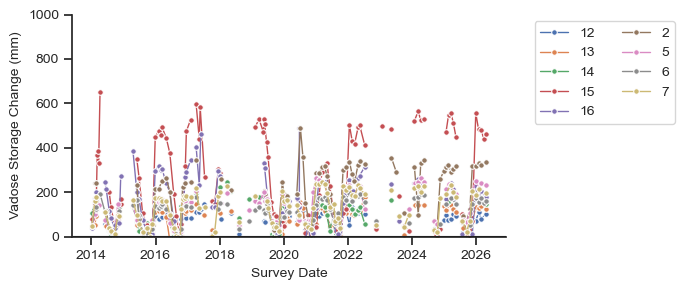

In [2]:
# ==========================================
# 1. DATA LOADING & DAISY-CHAIN CALIBRATION
# ==========================================
cv_threshold = 0.02
min_ref_count = 10
reference_probe = 'H340702152_01'
bad_probe = ''

sheet_url_raw = 'https://docs.google.com/spreadsheets/d/1l3VawfazqlWBqiykBNDvrWu8H-tJ7QltpAkppDlmgT0/export?format=csv&gid=1850041543'
df = pd.read_csv(sheet_url_raw, parse_dates=['Date'])
df.dropna(how='all', inplace=True)
df = df[(df['Site'] == 'Rivendell') & (df['Flag'].isna())].copy()

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Cable length (ft)'] = pd.to_numeric(df['Cable length (ft)'], errors='coerce')
df['Neutron Count (MD)'] = pd.to_numeric(df['Neutron Count (MD)'], errors='coerce')
df = df[df['Neutron Count (MD)'] <= 9000].copy()
df['Hole ID'] = df['Hole ID'].astype(str)
df.drop_duplicates(subset=['Cable length (ft)', 'Hole ID', 'Date'], inplace=True)

sheet_url_probe = 'https://docs.google.com/spreadsheets/d/1l3VawfazqlWBqiykBNDvrWu8H-tJ7QltpAkppDlmgT0/export?format=csv&gid=659019430'
probe_intervals = pd.read_csv(sheet_url_probe)
probe_intervals.rename(columns={
    'Date Lower': 'Start',
    'Date Upper': 'End',
    'New Conversion ID': 'Conversion ID'
}, inplace=True)
probe_intervals['Start'] = pd.to_datetime(probe_intervals['Start'], errors='coerce')
probe_intervals['End'] = pd.to_datetime(probe_intervals['End'], errors='coerce')
probe_intervals.sort_values('Start', inplace=True)

df.sort_values('Date', inplace=True)
merged = pd.merge_asof(
    df,
    probe_intervals[['Start', 'End', 'Conversion ID']],
    left_on='Date',
    right_on='Start',
    direction='backward'
)

df_cal = merged[merged['Date'] < merged['End']].copy()
df_cal.dropna(subset=['Conversion ID', 'Neutron Count (MD)'], inplace=True)
df_cal = df_cal[df_cal['Conversion ID'] != bad_probe].copy()

all_port_stats = df_cal.groupby(['Hole ID', 'Cable length (ft)', 'Conversion ID'])['Neutron Count (MD)'].agg(
    median='median', mean='mean', std='std', count='count'
).reset_index()

all_port_stats['cv'] = np.where(all_port_stats['mean'] == 0, 0, all_port_stats['std'] / all_port_stats['mean'])

ref_stats = all_port_stats[all_port_stats['Conversion ID'] == reference_probe]
true_invariant_ports = ref_stats[
    (ref_stats['cv'] < cv_threshold) & (ref_stats['count'] >= min_ref_count)
].copy()

valid_combos = pd.merge(all_port_stats, true_invariant_ports[['Hole ID', 'Cable length (ft)']], on=['Hole ID', 'Cable length (ft)'])
probe_pivot = valid_combos.pivot(index=['Hole ID', 'Cable length (ft)'], columns='Conversion ID', values='median').dropna(thresh=2)

known_probes = {reference_probe: {'global_slope': 1.0, 'global_intercept': 0.0, 'calibrated_to': None, 'chain_depth': 0}}
uncalibrated_probes = [p for p in probe_pivot.columns if p != reference_probe]

while uncalibrated_probes:
    best_match = None
    best_overlap = 2
    best_chain_depth = float('inf')

    for target in uncalibrated_probes:
        for known in known_probes.keys():
            overlap_data = probe_pivot[[target, known]].dropna()
            current_overlap = len(overlap_data)
            current_chain_depth = known_probes[known]['chain_depth']

            if current_overlap > 2:
                if (current_chain_depth < best_chain_depth) or (current_chain_depth == best_chain_depth and current_overlap > best_overlap):
                    best_overlap = current_overlap
                    best_chain_depth = current_chain_depth
                    best_match = (target, known, overlap_data)

    if not best_match:
        break

    target_probe, known_probe, overlap_data = best_match

    x = overlap_data[target_probe]
    y = overlap_data[known_probe]
    X_reg = x.values.reshape(-1, 1)
    y_reg = y.values

    ts = TheilSenRegressor(random_state=42).fit(X_reg, y_reg)
    slope = ts.coef_[0]
    intercept = ts.intercept_

    known_global_slope = known_probes[known_probe]['global_slope']
    known_global_intercept = known_probes[known_probe]['global_intercept']

    known_probes[target_probe] = {
        'global_slope': known_global_slope * slope,
        'global_intercept': known_global_slope * intercept + known_global_intercept,
        'calibrated_to': known_probe,
        'chain_depth': known_probes[known_probe]['chain_depth'] + 1
    }
    uncalibrated_probes.remove(target_probe)

df_cal['Adjusted Count'] = df_cal['Neutron Count (MD)']
for probe, params in known_probes.items():
    mask = df_cal['Conversion ID'] == probe
    df_cal.loc[mask, 'Adjusted Count'] = (
        df_cal.loc[mask, 'Neutron Count (MD)'] * params['global_slope'] + params['global_intercept']
    )

# ==========================================
# 2. DEPTH & THETA CONVERSION
# ==========================================
stickup_url = 'https://docs.google.com/spreadsheets/d/1l3VawfazqlWBqiykBNDvrWu8H-tJ7QltpAkppDlmgT0/export?format=csv&gid=474304226'
casing = pd.read_csv(stickup_url)
casing['Hole ID'] = casing['Hole ID'].astype(str)

df_full = pd.merge(df_cal, casing[['Hole ID', 'Wellhead height (m)']], on='Hole ID', how='left')
df_full.rename(columns={'Wellhead height (m)': 'wellhead stick up (m)'}, inplace=True)

ft_to_m = 0.3048
np_height = 0.3429
df_full['Depth (m)'] = (df_full['Cable length (ft)'] * ft_to_m) - df_full['wellhead stick up (m)'] - np_height

group1_ids = ['14', '15', '16']
group2_ids = ['1', '2', '3', '5', '6', '7', '10', '12', '13']
slope1, intercept1 = 0.000072, -0.029900
slope2, intercept2 = 0.000048, -0.015400

df_full['theta'] = np.nan
m1 = df_full['Hole ID'].isin(group1_ids)
m2 = df_full['Hole ID'].isin(group2_ids)

df_full.loc[m1, 'theta'] = df_full.loc[m1, 'Adjusted Count'] * slope1 + intercept1
df_full.loc[m2, 'theta'] = df_full.loc[m2, 'Adjusted Count'] * slope2 + intercept2

df_full.dropna(subset=['theta', 'Depth (m)'], inplace=True)

reference_date = pd.to_datetime('2015-10-25')
ref_df = df_full[df_full['Date'] == reference_date][['Hole ID', 'Cable length (ft)', 'theta']].rename(columns={'theta': 'theta_ref'})

df_full = pd.merge(df_full, ref_df, on=['Hole ID', 'Cable length (ft)'], how='left')
df_full['delta_theta'] = df_full['theta'] - df_full['theta_ref']
df_full.dropna(subset=['delta_theta'], inplace=True)

# ==========================================
# 3. BASELINE SUBTRACTION & INTEGRATION
# ==========================================
z_min = 0.5

gw_high_water_marks = {
    '15': 10.0,
    '10': 10.0,
    '1': 5.0,
    '12': 5.0,
    '16': 10.0,
    '2': 10.0,
    '3': 5.0,
    '5': 5.0,
    '6': 5.0,
    '7': 5.0,
}

default_max_depth = 5.0
storage_records = []

for (hole_id, date), group in df_full.groupby(['Hole ID', 'Date']):
    group = group.sort_values('Depth (m)')
    z = group['Depth (m)'].values
    theta_diff = group['delta_theta'].values

    if len(z) < 2:
        continue

    z_max = gw_high_water_marks.get(str(hole_id), default_max_depth)
    actual_z_max = min(z_max, z[-1])

    if actual_z_max <= z_min:
        continue

    z_fine = np.linspace(z_min, actual_z_max, 500)

    f = interp1d(z, theta_diff, kind='linear', bounds_error=False, fill_value=(theta_diff[0], theta_diff[-1]))
    theta_fine = f(z_fine)

    total_storage_mm = trapezoid(theta_fine, z_fine) * 1000

    storage_records.append({
        'Hole ID': hole_id,
        'Date': date,
        'Total Storage Change (mm)': total_storage_mm
    })

storage_ts = pd.DataFrame(storage_records)
storage_ts['Date'] = pd.to_datetime(storage_ts['Date'])
storage_ts = storage_ts[storage_ts['Date'] >= '2014-01-01'].copy()
storage_ts.sort_values(['Hole ID', 'Date'], inplace=True)

storage_ts = storage_ts[
    (storage_ts['Total Storage Change (mm)'] > -100) &
    (storage_ts['Total Storage Change (mm)'] < 1500)
].copy()

gap_threshold = pd.Timedelta(days=60)
storage_ts['time_diff'] = storage_ts.groupby('Hole ID')['Date'].diff()
storage_ts['is_new_segment'] = storage_ts['time_diff'] > gap_threshold
storage_ts['segment_id'] = storage_ts.groupby('Hole ID')['is_new_segment'].cumsum()
storage_ts['line_group'] = storage_ts['Hole ID'].astype(str) + "_" + storage_ts['segment_id'].astype(str)

# ==========================================
# 4. PLOTTING
# ==========================================
fig, ax = plt.subplots(figsize=(7, 3))

sns.lineplot(
    data=storage_ts,
    x='Date',
    y='Total Storage Change (mm)',
    hue='Hole ID',
    units='line_group',
    estimator=None,
    marker='o',
    markersize=4,
    linewidth=1,
    ax=ax
)

ax.axhline(0, color='black', linewidth=1.5)
ax.set_ylim(0, 1000)
ax.set_xlabel('Survey Date')
ax.set_ylabel('Vadose Storage Change (mm)')
ax.grid(False)
sns.despine(ax=ax)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

storage_ts.to_csv("./Data/storage_ts.csv", index=False)

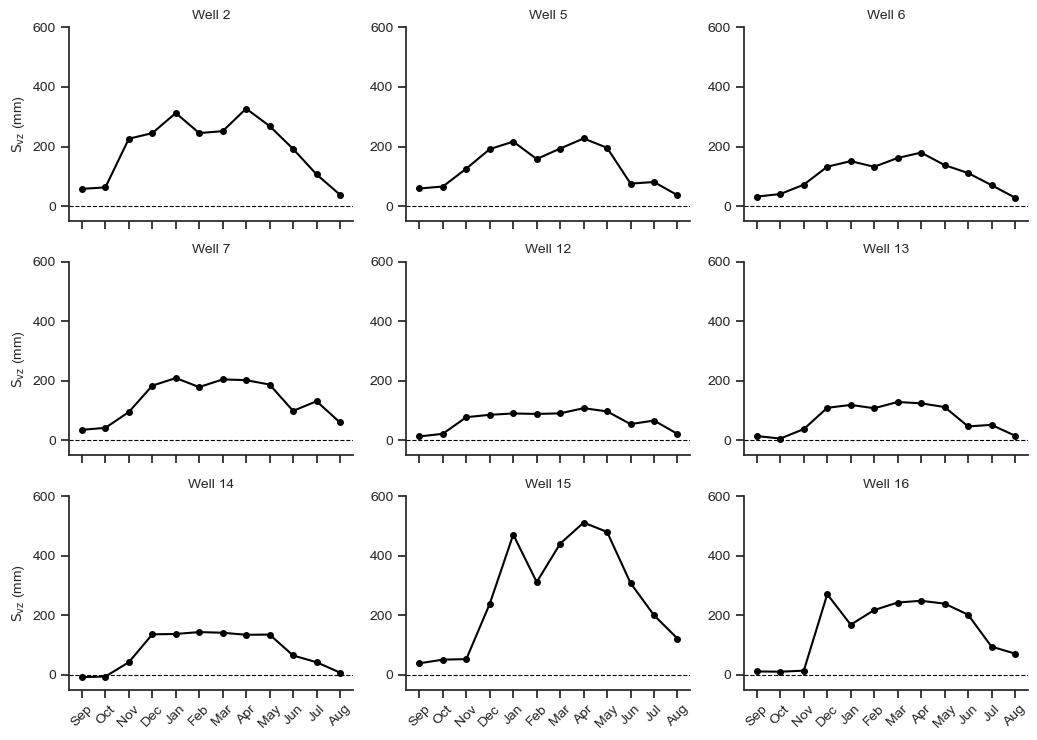

In [3]:
df_stats = storage_ts.dropna(subset=['Total Storage Change (mm)']).copy()

# Using September as month 1 based on your recharge_year logic
def get_recharge_month(date):
    return date.month - 8 if date.month >= 9 else date.month + 4

df_stats['Recharge_Month'] = df_stats['Date'].apply(get_recharge_month)

monthly_stats = df_stats.groupby(['Hole ID', 'Recharge_Month'])['Total Storage Change (mm)'].median().reset_index()

sorted_holes = sorted(monthly_stats['Hole ID'].unique(), key=lambda x: int(x) if x.isdigit() else x)

ncols = 3
nrows = math.ceil(len(sorted_holes) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 3.5, nrows * 2.5), sharex=True)
axes = axes.flatten()

# Map the numeric sequence back to month names for the x-axis
month_labels = {1:'Sep', 2:'Oct', 3:'Nov', 4:'Dec', 5:'Jan', 6:'Feb', 7:'Mar', 8:'Apr', 9:'May', 10:'Jun', 11:'Jul', 12:'Aug'}

for i, hole in enumerate(sorted_holes):
    ax = axes[i]
    hole_data = monthly_stats[monthly_stats['Hole ID'] == hole].sort_values('Recharge_Month')

    ax.plot(hole_data['Recharge_Month'], hole_data['Total Storage Change (mm)'],
            color='black', lw=1.5, marker='o', markersize=4, label=f'Well {hole}')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    ax.set_xticks(list(month_labels.keys()))
    if i >= len(sorted_holes) - ncols:
        ax.set_xticklabels(list(month_labels.values()), rotation=45)

    if i % ncols == 0:
        ax.set_ylabel(r'$\mathrm{S_{vz}}$ (mm)')
    ax.set_title('Well %s'%hole)

    sns.despine(ax=ax)
    ax.set_ylim(-50,600)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

os.makedirs('./Plots', exist_ok=True)
png_filename_monthly = os.path.join('./Plots', 'rivendell_monthly_dynamics_grid.png')
plt.savefig(png_filename_monthly, dpi=300, bbox_inches='tight')
plt.show()

/var/folders/rm/s2gw2gh1089b_cwdw20lz48m0000gn/T/ipykernel_8065/2356693623.py:139: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc=legend_loc, fontsize=8, frameon=False)
/var/folders/rm/s2gw2gh1089b_cwdw20lz48m0000gn/T/ipykernel_8065/2356693623.py:139: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc=legend_loc, fontsize=8, frameon=False)


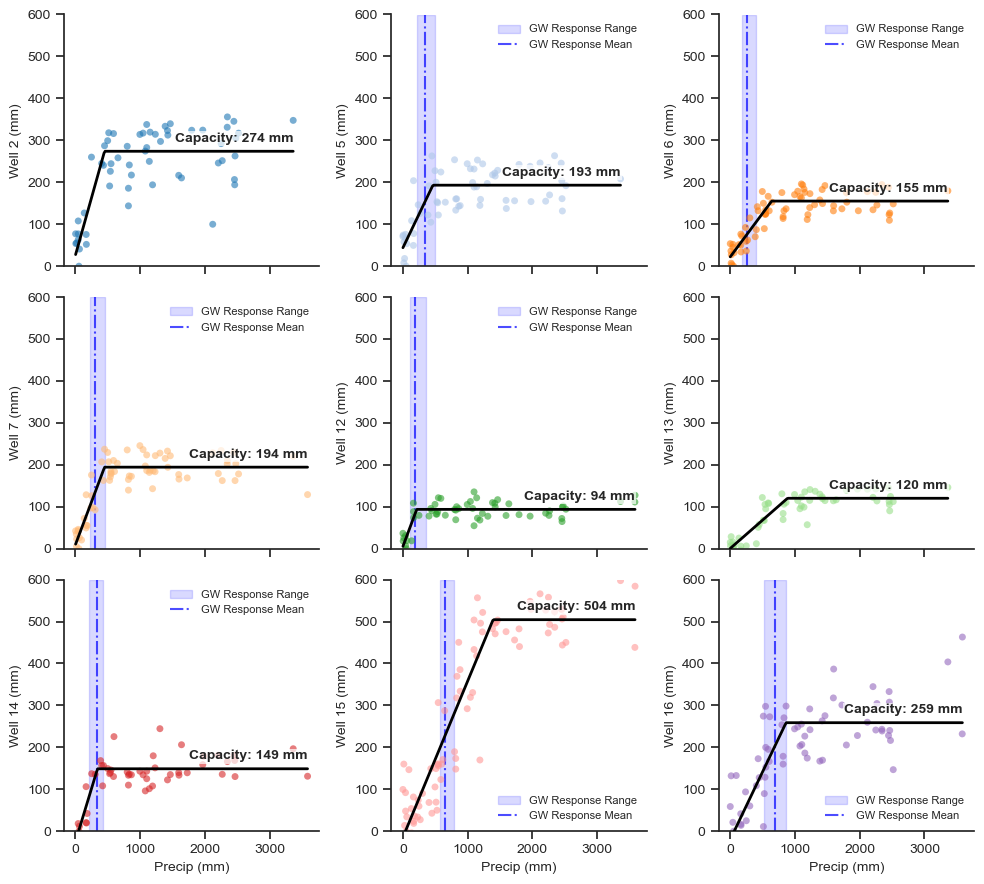


\begin{table}[htpb]
\centering
\caption{Estimated hillslope vadose zone storage capacities. Bedrock storage capacities ($S_{bedrock}$) were determined by piecewise horizontal fitting of cumulative precipitation against calculated bedrock vadose zone storage. Total vadose zone capacity ($S_{vz}$) includes a uniform 60~mm soil storage capacity.}
\label{tab:storage_capacities}
\begin{tabular}{lcc}
\hline
\textbf{Well ID} & \textbf{$S_{bedrock}$ (mm)} & \textbf{$S_{vz}$ ($S_{bedrock}$ + 60~mm)} \\
\hline
2 & 274 & 334 \\
5 & 193 & 253 \\
6 & 155 & 215 \\
7 & 194 & 254 \\
12 & 94 & 154 \\
13 & 120 & 180 \\
14 & 149 & 209 \\
15 & 504 & 564 \\
16 & 259 & 319 \\
\hline
\end{tabular}
\end{table}



In [4]:
font_size = 10
plt.rcParams.update({
    'font.size': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size
})
sns.set_theme(style="ticks")

def piecewise_flat(x, x0, y0, k1):
    return np.where(x < x0, k1 * (x - x0) + y0, y0)

gw_response_stats = {
    '5': {'mean': 348, 'min': 227, 'max': 492},
    '6': {'mean': 263, 'min': 179, 'max': 394},
    '7': {'mean': 301, 'min': 224, 'max': 456},
    '12': {'mean': 190, 'min': 105, 'max': 358},
    '14': {'mean': 332, 'min': 208, 'max': 418},
    '15': {'mean': 651, 'min': 574, 'max': 794},
    '16': {'mean': 693, 'min': 524, 'max': 860}
}

storage_ts['Date_daily'] = storage_ts['Date'].dt.floor('D')

ppt_file = "./Data/prism_ppt.csv"
df_ppt = pd.read_csv(ppt_file)

if 'Date' in df_ppt.columns:
    df_ppt['Date'] = pd.to_datetime(df_ppt['Date'])
    df_ppt.set_index('Date', inplace=True)
elif 'date' in df_ppt.columns:
    df_ppt['date'] = pd.to_datetime(df_ppt['date'])
    df_ppt.set_index('date', inplace=True)
else:
    df_ppt.index = pd.to_datetime(df_ppt.index)

if 'ppt (inches)' in df_ppt.columns:
    df_ppt['ppt_mm'] = df_ppt['ppt (inches)'] * 25.4
else:
    df_ppt['ppt_mm'] = df_ppt['ppt']

df_ppt.sort_index(inplace=True)

# Calculate cumulative precipitation by water year (starting Sept 1st)
df_ppt['recharge_year'] = df_ppt.index.year
df_ppt.loc[df_ppt.index.month >= 9, 'recharge_year'] += 1
df_ppt['cum_ppt_mm'] = df_ppt.groupby('recharge_year')['ppt_mm'].cumsum()

df_plot = pd.merge(
    storage_ts,
    df_ppt[['cum_ppt_mm', 'recharge_year']],
    left_on='Date_daily',
    right_index=True,
    how='inner'
)

start_month = 10
end_month = 5

if start_month > end_month:
    valid_months = list(range(start_month, 13)) + list(range(1, end_month + 1))
else:
    valid_months = list(range(start_month, end_month + 1))

mask = df_plot['Date_daily'].dt.month.isin(valid_months)
df_plot = df_plot[mask].copy()

valid_wells = sorted(df_plot['Hole ID'].unique(), key=int)
cols = 3
rows = int(np.ceil(len(valid_wells) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows), sharex=True, sharey=False)
axes = axes.flatten()

colors = sns.color_palette("tab20", len(valid_wells))

# --- DICTIONARY TO STORE CALCULATED CAPACITIES ---
calculated_capacities = {}

for i, w in enumerate(valid_wells):
    ax = axes[i]
    well_data = df_plot[df_plot['Hole ID'] == w].dropna(subset=['cum_ppt_mm', 'Total Storage Change (mm)'])

    x_data = well_data['cum_ppt_mm'].values
    y_data = well_data['Total Storage Change (mm)'].values

    ax.scatter(x_data, y_data, color=colors[i % 20], s=25, alpha=0.6, edgecolor='none', zorder=2)

    if str(w) in gw_response_stats:
        stats = gw_response_stats[str(w)]
        ax.axvspan(stats['min'], stats['max'], color='blue', alpha=0.15, zorder=0, label='GW Response Range')
        ax.axvline(stats['mean'], color='blue', linestyle='-.', alpha=0.7, zorder=1, label='GW Response Mean')

    legend_loc = 'upper right'

    if len(x_data) > 4:
        x0_guess = np.median(x_data)
        y0_guess = np.max(y_data)

        x_range = (x0_guess - np.min(x_data))
        if x_range == 0: x_range = 1.0
        k1_guess = (y0_guess - np.min(y_data)) / x_range

        p0 = [x0_guess, y0_guess, k1_guess]
        bounds = ([np.min(x_data), -np.inf, 0], [np.max(x_data), np.inf, np.inf])

        try:
            popt, pcov = curve_fit(piecewise_flat, x_data, y_data, p0=p0, bounds=bounds)
            x0_fit, y0_fit, k1_fit = popt

            # --- SAVE THE CAPACITY FOR THE LATEX TABLE ---
            calculated_capacities[str(w)] = y0_fit

            if y0_fit > 200:
                legend_loc = 'lower right'
            else:
                legend_loc = 'upper right'

            x_fit = np.linspace(np.min(x_data), np.max(x_data), 200)
            y_fit = piecewise_flat(x_fit, *popt)

            ax.plot(x_fit, y_fit, color='black', linewidth=2, linestyle='-', zorder=3)

            ax.text(np.max(x_data), y0_fit + 15, f"Capacity: {y0_fit:.0f} mm",
                    ha='right', va='bottom', fontsize=font_size, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        except RuntimeError:
            pass

    ax.set_ylabel(f"Well {w} (mm)", fontsize=font_size)
    ax.tick_params(labelsize=font_size)
    ax.grid(False)

    if i >= len(valid_wells) - cols:
        ax.set_xlabel("Precip (mm)", fontsize=font_size)
    else:
        ax.set_xlabel("")

    ax.legend(loc=legend_loc, fontsize=8, frameon=False)
    sns.despine(ax=ax)
    ax.set_ylim(0, 600)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plots_dir = "./Plots"
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)
plt.savefig(os.path.join(plots_dir, "storage_capacity_horizontal_fit.png"), dpi=150, bbox_inches="tight")
plt.show()
# ==========================================
# GENERATE LATEX TABLE FOR STORAGE CAPACITIES
# ==========================================
s_soil = 60

# Sort the wells that successfully fit
sorted_table_wells = sorted(calculated_capacities.keys(), key=int)

latex_str = "\n\\begin{table}[htpb]\n"
latex_str += "\\centering\n"
latex_str += "\\caption{Estimated hillslope vadose zone storage capacities. Bedrock storage capacities ($S_{bedrock}$) were determined by piecewise horizontal fitting of cumulative precipitation against calculated bedrock vadose zone storage. Total vadose zone capacity ($S_{vz}$) includes a uniform 60~mm soil storage capacity.}\n"
latex_str += "\\label{tab:storage_capacities}\n"
latex_str += "\\begin{tabular}{lcc}\n"
latex_str += "\\hline\n"
latex_str += "\\textbf{Well ID} & \\textbf{$S_{bedrock}$ (mm)} & \\textbf{$S_{vz}$ ($S_{bedrock}$ + 60~mm)} \\\\\n"
latex_str += "\\hline\n"

for well in sorted_table_wells:
    bedrock = round(calculated_capacities[well])
    vz = bedrock + s_soil
    latex_str += f"{well} & {bedrock} & {vz} \\\\\n"

latex_str += "\\hline\n"
latex_str += "\\end{tabular}\n"
latex_str += "\\end{table}\n"

print(latex_str)

# Export full dataset

In [5]:
# ==========================================
# EXPORT DEPTH & THETA TIME SERIES TO CSV
# ==========================================

# Select the requested columns
export_cols = ['Hole ID', 'Date', 'Depth (m)', 'theta']

# Create a clean dataframe for export and sort it logically
df_export = df_full[export_cols].copy()
df_export.sort_values(by=['Hole ID', 'Date', 'Depth (m)'], inplace=True)

# Define the output filename
csv_filename = "./Data/rivendell_theta_depth_timeseries.csv"

# Save to CSV without the index
df_export.to_csv(csv_filename, index=False)

# Trigger the download to your local machine

print(f"Successfully generated {csv_filename} with {len(df_export)} records.")

Successfully generated ./Data/rivendell_theta_depth_timeseries.csv with 41749 records.
